Task 1: Dataset Exploration

**1.Load the dataset and display the first five records.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/ANN/diabetes.csv')
df.head()


Mounted at /content/drive


,id,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,...,citoglipton,insulin,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed,readmitted
0,1,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,...,No,No,No,No,No,No,No,No,No,NO
1,2,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,3,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,...,No,No,No,No,No,No,No,No,Yes,NO
3,4,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,5,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


# 2. Display dataset dimensions and data types


In [2]:
print("Dataset Shape (Rows, Columns):")
print(df.shape)

print("Data Types:")
print(df.dtypes)

Dataset Shape (Rows, Columns):
(101766, 51)
Data Types:
id                           int64
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object

# 3. Identify missing or invalid values

In [3]:
print("Missing Values:")
print(df.isnull().sum())

print("Duplicate Rows:", df.duplicated().sum())

Missing Values:
id                              0
encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  

# 4. Visualize the distribution of the target variable

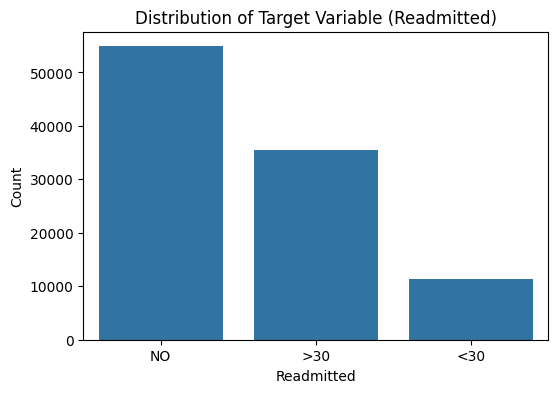

In [4]:
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(x='readmitted', data=df)
plt.title("Distribution of Target Variable (Readmitted)")
plt.xlabel("Readmitted")
plt.ylabel("Count")
plt.show()

# 5. Compute and visualize the correlation matrix

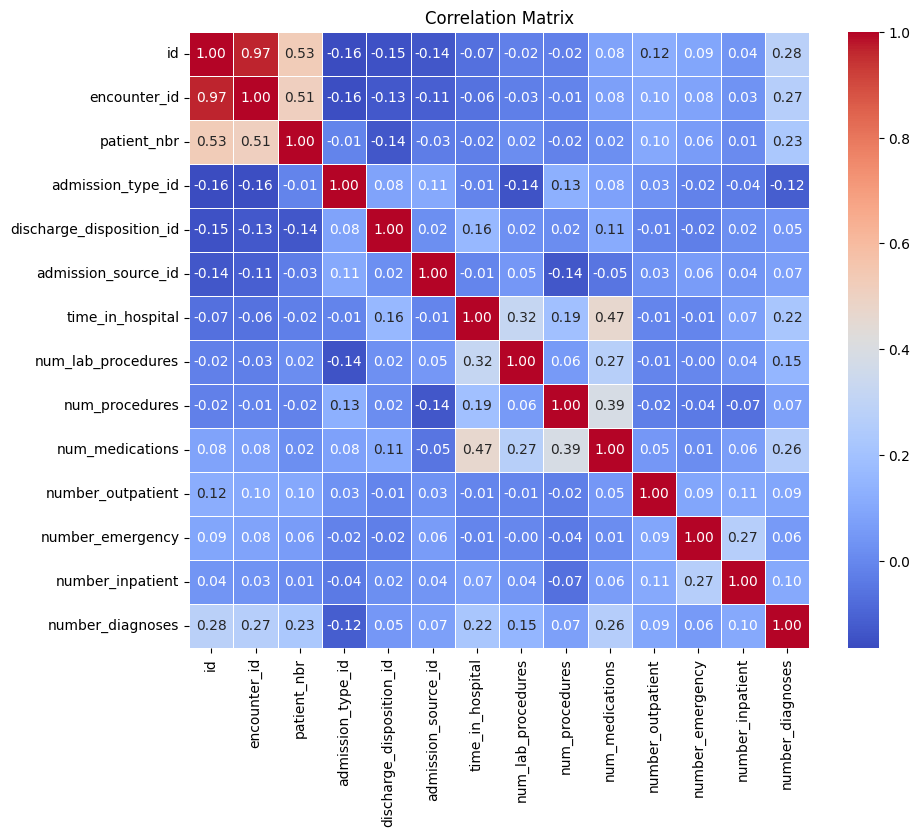

In [5]:
plt.figure(figsize=(10,8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Matrix")
plt.show()

# Task:02
# **Data Preparation**

**Step 6: Separate Input Features and Target Variable**

6.1:Create terget

In [6]:
# Convert readmitted into binary target

df['target'] = df['readmitted'].apply(
    lambda x: 1 if x == '>30' else 0
)

# Check target
print(df['target'].value_counts())

target
0    66221
1    35545
Name: count, dtype: int64


Step 6.2 — Input Features (X) এবং Target (y) আলাদা করা

In [7]:
# Columns that we don't need
drop_columns = [
    'readmitted',
    'id',
    'encounter_id',
    'patient_nbr',
    'diag_1',
    'diag_2',
    'diag_3',
    'examide',
    'citoglipton'
]

# Input features
X = df.drop(columns=drop_columns + ['target'])

# Target variable
y = df['target']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (101766, 42)
y shape: (101766,)


7.Perform the necessary preprocessing steps to prepare the dataset for ANN training.

7.1: ? কে Missing Value বানানো

In [8]:
# Replace '?' with NaN
import numpy as np
X = X.replace('?', np.nan)

print("Missing values:")
print(X.isnull().sum().sort_values(ascending=False).head(15))

Missing values:
weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
discharge_disposition_id        0
admission_type_id               0
gender                          0
age                             0
admission_source_id             0
time_in_hospital                0
num_medications                 0
num_lab_procedures              0
number_outpatient               0
dtype: int64


7.2 — Numerical এবং Categorical columns identify করা

In [9]:
# Numerical columns
numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns

# Categorical columns
categorical_features = X.select_dtypes(
    include=['object']
).columns

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))
print("Numerical features:")
print(list(numeric_features))

print("Categorical features:")
print(list(categorical_features))

Number of numerical features: 11
Number of categorical features: 31
Numerical features:
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
Categorical features:
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide.metformin', 'glipizide.metformin', 'glimepiride.pioglitazone', 'metformin.rosiglitazone', 'metformin.pioglitazone', 'change', 'diabetesMed']


7.3 — Preprocessing Pipeline তৈরি করা

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

#Numerical Processing
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

#Categorical Processing
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ))
    ]
)

Step 7.4 — দুইটা preprocessing একসাথে করা

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

8.Split the dataset into training, validation, and testing sets.

Step 8.1 — Training এবং Temporary Data

In [12]:
from sklearn.model_selection import train_test_split

# 70% Training
# 30% Temporary

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Temporary data:", X_temp.shape)

Training data: (71236, 42)
Temporary data: (30530, 42)


Step 8.2 — Validation এবং Testing আলাদা করা

In [13]:
# Split temporary data into validation and test
# 15% validation
# 15% test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (71236, 42)
Validation: (15265, 42)
Testing: (15265, 42)


**Task 3: ANN Design**

9.Design an ANN architecture suitable for binary classification using Keras/TensorFlow.

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# Number of input features
input_dim = X_train.shape[1]

# Create ANN model
model = Sequential([
    Input(shape=(input_dim,)), # Using Input layer as recommended
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

print("ANN model created successfully.")

ANN model created successfully.


10. Print the model summary showing architecture and trainable parameters

In [16]:
# Task 3 - Question 10
# Print Model Summary

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

**Task 4: Model Configuration**

11.Compile the ANN by selecting appropriate optimizer, loss function, and evaluation metrics

In [17]:
# Task 4 - Question 11
# Compile the ANN

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

print("ANN model compiled successfully.")

ANN model compiled successfully.


12. Justify your choice of activation functions for the hidden and output layers through implementation.

In [23]:
# Task 4 - Question 12
# Activation Functions

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
import tensorflow as tf # Import tensorflow for metrics

# Number of input features
input_dim = X_train.shape[1]

# ANN architecture
model = Sequential([
    Input(shape=(input_dim,)), # Using Input layer as recommended
    # Hidden Layer 1 - ReLU
    Dense(64, activation='relu'),

    # Hidden Layer 2 - ReLU
    Dense(32, activation='relu'),

    # Dropout
    Dropout(0.3),

    # Output Layer - Sigmoid
    Dense(1, activation='sigmoid')
])

# Display model architecture
model.summary()

# Recompile the model after re-definition
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

**Task 5: Model Training**


13. Train the ANN using appropriate hyperparameters

In [25]:
# Task 5 - Question 13
# Train the ANN

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# Apply preprocessing to training and validation data
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

# Recalculate input_dim based on processed data
input_dim = X_train_processed.shape[1]

# Redefine the model with the correct input dimension
model = Sequential([
    Input(shape=(input_dim,)), # Using Input layer as recommended
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Recompile the model with the chosen optimizer, loss function, and metrics
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

history = model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=30,
    batch_size=256,
    verbose=1
)

Epoch 1/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6477 - auc: 0.5911 - loss: 0.6376 - precision: 0.4764 - recall: 0.0860 - val_accuracy: 0.6531 - val_auc: 0.6232 - val_loss: 0.6259 - val_precision: 0.5142 - val_recall: 0.1225
Epoch 2/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6555 - auc: 0.6234 - loss: 0.6262 - precision: 0.5366 - recall: 0.0998 - val_accuracy: 0.6544 - val_auc: 0.6273 - val_loss: 0.6241 - val_precision: 0.5327 - val_recall: 0.0855
Epoch 3/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6595 - auc: 0.6313 - loss: 0.6233 - precision: 0.5592 - recall: 0.1187 - val_accuracy: 0.6544 - val_auc: 0.6309 - val_loss: 0.6265 - val_precision: 0.5138 - val_recall: 0.1949
Epoch 4/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6600 - auc: 0.6366 - loss: 0.6209 - precision: 0.5539 - recall: 0.1372 - val_accuracy: 0.6561 - val_auc: 0.6337 - val_loss: 0.6215 - val_precision: 0.5295 - val_recall: 0.1395
Epoch 5/30
279/279 ━━━━━━━━━━━━━

14. Store the training history for further analysis.

In [28]:
# Task 5 - Question 14
# Display Training History

print(history.history.keys())
print(history.history['accuracy'])
print(history.history['val_accuracy'])
print(history.history['loss'])
print(history.history['val_loss'])

dict_keys(['accuracy', 'auc', 'loss', 'precision', 'recall', 'val_accuracy', 'val_auc', 'val_loss', 'val_precision', 'val_recall'])
[0.6477483510971069, 0.6554831862449646, 0.6594980359077454, 0.6600455045700073, 0.6614071726799011, 0.6633303165435791, 0.6645937561988831, 0.6637654900550842, 0.6649166345596313, 0.6682575941085815, 0.6681874394416809, 0.6678926348686218, 0.6692683696746826, 0.6703913807868958, 0.6720197796821594, 0.6733112335205078, 0.6734796762466431, 0.674588680267334, 0.6762170791625977, 0.6777051091194153, 0.678631603717804, 0.678631603717804, 0.681003987789154, 0.6818041205406189, 0.6831237077713013, 0.6828991174697876, 0.6832781434059143, 0.6842186450958252, 0.6839098334312439, 0.6851030588150024]
[0.6530625820159912, 0.6543727517127991, 0.6543727517127991, 0.6561415195465088, 0.6576482057571411, 0.6560105085372925, 0.6560105085372925, 0.6550933718681335, 0.6596789956092834, 0.6554208993911743, 0.6537176370620728, 0.6582378149032593, 0.6527349948883057, 0.65797573

**Task 6: Performance Evaluation**

15. Evaluate the trained model using the test dataset.

In [30]:
# Task 6 - Question 15
# Evaluate the trained ANN on test dataset

# Preprocess X_test using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

test_results = model.evaluate(
    X_test_processed,
    y_test,
    verbose=1
)

print("Test Evaluation Completed.")

478/478 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6602 - auc: 0.6340 - loss: 0.6298 - precision: 0.5411 - recall: 0.1789
Test Evaluation Completed.


16. Compute the following performance measures:Accuracy
Precision
Recall
F1-score
ROC-AUC Score


In [31]:
# Task 6 - Question 16
# Make predictions on test dataset

import numpy as np

# Predicted probabilities
y_prob = model.predict(
    X_test_processed
).ravel()

# Convert probabilities into binary classes
y_pred = (y_prob >= 0.5).astype(int)

478/478 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Calculate performance metrics

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


# Display results

print("Performance Measures")
print("----------------------------")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Performance Measures
----------------------------
Accuracy  : 0.6602
Precision : 0.5411
Recall    : 0.1789
F1-score  : 0.2689
ROC-AUC   : 0.6340


17. Generate and Visualize Confusion Matrix

Confusion Matrix:
[[9124  809]
 [4378  954]]


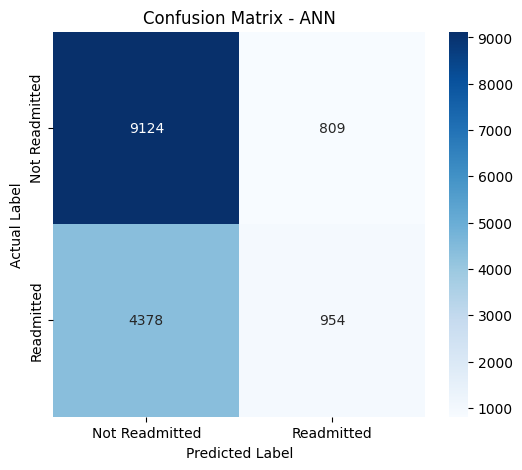

In [34]:
# Task 6 - Question 17
# Generate Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)
# Visualize Confusion Matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Readmitted', 'Readmitted'],
    yticklabels=['Not Readmitted', 'Readmitted']
)

plt.title("Confusion Matrix - ANN")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

**Task:07** **Learning Analysis**

18. Plot the training and validation accuracy over epochs.

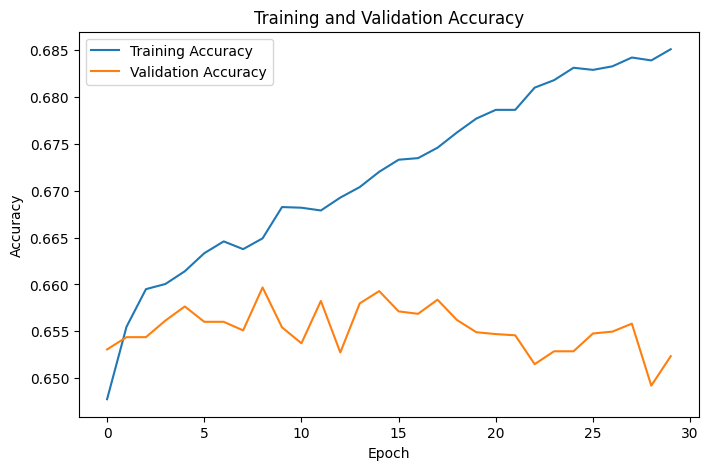

In [35]:
# Task 7 - Question 18
# Plot Training and Validation Accuracy

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

19. Training and Validation Loss over Epochs

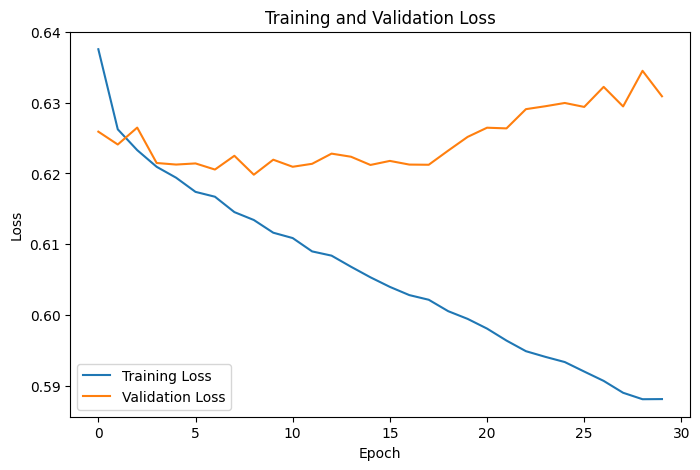

In [36]:
# Task 7 - Question 19
# Plot Training and Validation Loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

20. Based on the learning curves, determine whether the model exhibits underfitting or overfitting

In [37]:
# Task 7 - Question 20
# Check for possible overfitting or underfitting

train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

print("Final Training Accuracy :", train_acc)
print("Final Validation Accuracy:", val_acc)

print("Final Training Loss :", train_loss)
print("Final Validation Loss:", val_loss)


# Simple interpretation

if train_acc > val_acc + 0.05 and val_loss > train_loss:
    print("\nResult: The model shows signs of OVERFITTING.")

elif train_acc < 0.70 and val_acc < 0.70:
    print("\nResult: The model shows signs of UNDERFITTING.")

else:
    print("\nResult: The model appears to be reasonably well-fitted.")

Final Training Accuracy : 0.6851030588150024
Final Validation Accuracy: 0.6523419618606567
Final Training Loss : 0.5880931615829468
Final Validation Loss: 0.6309188008308411

Result: The model shows signs of UNDERFITTING.


**Task 8: Architecture Improvement**

21. Modify the ANN architecture by changing at least one of the following:
Number of hidden layers
Number of neurons
Activation function
Optimizer


In [38]:
# ==========================================
# Task 8 - Question 21
# Modified ANN Architecture
# ==========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Number of input features
input_dim = X_train_processed.shape[1]

# Create Modified ANN
model2 = Sequential([

    # First Hidden Layer
    Dense(128, activation='relu', input_shape=(input_dim,)),

    # Dropout
    Dropout(0.3),

    # Second Hidden Layer
    Dense(64, activation='relu'),

    # Third Hidden Layer
    Dense(32, activation='relu'),

    # Output Layer
    Dense(1, activation='sigmoid')
])

# Display modified architecture
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 128)            │        25,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,097 (141.00 KB)

 Trainable params: 36,097 (141.00 KB)

 Non-trainable params: 0 (0.00 B)

22. Retrain the Modified Model

In [41]:
# Compile Modified Model

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)
# ==========================================
# Task 8 - Question 22
# Train Modified ANN
# ==========================================

history2 = model2.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=30,
    batch_size=256,
    verbose=1
)
# Make predictions using Modified Model

y_prob2 = model2.predict(
    X_test_processed
).ravel()

y_pred2 = (
    y_prob2 >= 0.5
).astype(int)

Epoch 1/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6889 - auc: 0.7050 - loss: 0.5839 - precision: 0.6016 - recall: 0.3237 - val_accuracy: 0.6498 - val_auc: 0.6331 - val_loss: 0.6298 - val_precision: 0.4970 - val_recall: 0.2192
Epoch 2/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6889 - auc: 0.7072 - loss: 0.5821 - precision: 0.5999 - recall: 0.3282 - val_accuracy: 0.6497 - val_auc: 0.6365 - val_loss: 0.6261 - val_precision: 0.4972 - val_recall: 0.2538
Epoch 3/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6891 - auc: 0.7082 - loss: 0.5817 - precision: 0.6017 - recall: 0.3254 - val_accuracy: 0.6503 - val_auc: 0.6339 - val_loss: 0.6303 - val_precision: 0.4989 - val_recall: 0.2571
Epoch 4/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6913 - auc: 0.7094 - loss: 0.5806 - precision: 0.6058 - recall: 0.3327 - val_accuracy: 0.6493 - val_auc: 0.6324 - val_loss: 0.6298 - val_precision: 0.4964 - val_recall: 0.2691
Epoch 5/30
279/279 ━━━━━━━━━━━━━

23.Compare the performance of both models.

In [43]:
# Task 8 - Question 23
# Compare Original ANN and Modified ANN

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

# -----------------------------
# Model 1 Performance
# -----------------------------

accuracy1 = accuracy_score(y_test, y_pred)
precision1 = precision_score(y_test, y_pred)
recall1 = recall_score(y_test, y_pred)
f1_1 = f1_score(y_test, y_pred)
roc_auc1 = roc_auc_score(y_test, y_prob)


# -----------------------------
# Model 2 Performance
# -----------------------------

accuracy2 = accuracy_score(y_test, y_pred2)
precision2 = precision_score(y_test, y_pred2)
recall2 = recall_score(y_test, y_pred2)
f1_2 = f1_score(y_test, y_pred2)
roc_auc2 = roc_auc_score(y_test, y_prob2)


# -----------------------------
# Comparison Table
# -----------------------------

comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score',
        'ROC-AUC'
    ],

    'Original ANN': [
        accuracy1,
        precision1,
        recall1,
        f1_1,
        roc_auc1
    ],

    'Modified ANN': [
        accuracy2,
        precision2,
        recall2,
        f1_2,
        roc_auc2
    ]
})

display(comparison)

,Metric,Original ANN,Modified ANN
0,Accuracy,0.660203,0.644939
1,Precision,0.541123,0.485668
2,Recall,0.178920,0.279632
3,F1-score,0.268922,0.354915
4,ROC-AUC,0.634031,0.629478


Comparison Graph

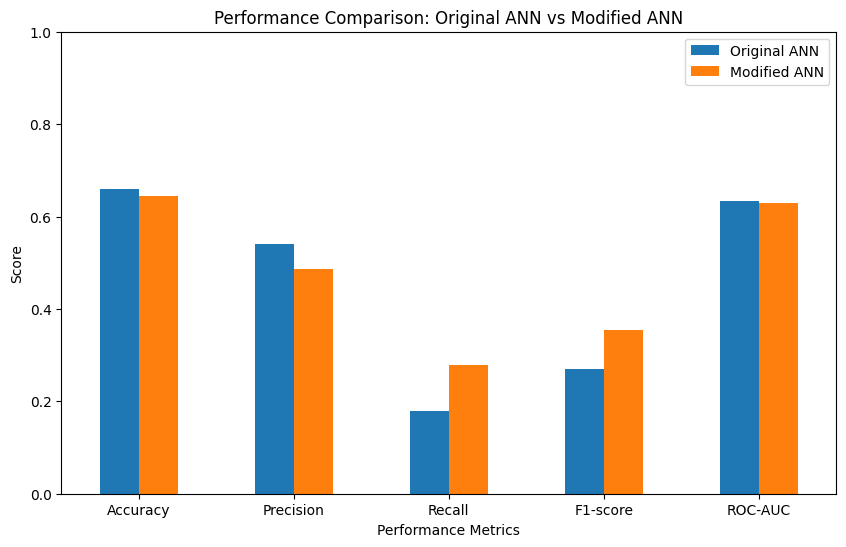

In [44]:
# Visualize comparison

comparison.set_index('Metric').plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Performance Comparison: Original ANN vs Modified ANN')
plt.xlabel('Performance Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend()

plt.show()

# **Nicher gulo ar lagbena**

# Task:02
# **Data Preparation**

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 1. Create a copy of the dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/ANN/diabetes.csv')
df.head()

df_processed = df.copy()

# 2. Replace '?' with NaN

In [ ]:
df_processed.replace('?', pd.NA, inplace=True)

# 3. Handle missing values

In [ ]:
for col in df_processed.select_dtypes(include='object').columns:
    df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0])

for col in df_processed.select_dtypes(exclude='object').columns:
    df_processed[col] = df_processed[col].fillna(df_processed[col].median())

# 4. Label Encode categorical columns

In [ ]:
label_encoders = {}

# Explicitly encode 'readmitted' column as binary (0 or 1)
df_processed['readmitted'] = df_processed['readmitted'].replace({
    'NO': 0,
    '>30': 1,
    '<30': 1
}).astype(float) # Cast to float for binary_crossentropy

# Label Encode other categorical columns, skipping 'readmitted'
for col in df_processed.select_dtypes(include='object').columns:
    if col != 'readmitted': # Skip 'readmitted' as it's already handled
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
        label_encoders[col] = le

# 5. Separate features and target

In [ ]:
X = df_processed.drop('readmitted', axis=1)
y = df_processed['readmitted']

# 6. Feature Scaling


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Split into Training and Testing Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 8. Display Results

In [ ]:
print("Feature matrix shape:", X_scaled.shape)
print("Target shape:", y.shape)

print("\nTraining set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Feature matrix shape: (101766, 50)
Target shape: (101766,)

Training set:
X_train: (81412, 50)
y_train: (81412,)

Testing set:
X_test: (20354, 50)
y_test: (20354,)


Task:03

In [ ]:
df['readmitted'] = df['readmitted'].replace({
    'NO': 0,
    '>30': 1,
    '<30': 1
})

/tmp/ipykernel_14196/831890262.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['readmitted'] = df['readmitted'].replace({


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,377 (21.00 KB)

 Trainable params: 5,377 (21.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,377 (21.00 KB)

 Trainable params: 5,377 (21.00 KB)

 Non-trainable params: 0 (0.00 B)

Task:04


In [ ]:
from tensorflow.keras.optimizers import Adam

# Compile the ANN model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
print("Optimizer :", model.optimizer.__class__.__name__)
print("Loss Function :", model.loss)
print("Evaluation Metric :", model.metrics_names)

Optimizer : Adam
Loss Function : binary_crossentropy
Evaluation Metric : ['loss', 'compile_metrics']


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

Task:05

In [ ]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2545/2545 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.5579 - loss: 0.9274 - val_accuracy: 0.5809 - val_loss: 0.8921
Epoch 2/30
2545/2545 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.5785 - loss: 0.8981 - val_accuracy: 0.5849 - val_loss: 0.8871
Epoch 3/30
2545/2545 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5839 - loss: 0.8910 - val_accuracy: 0.5883 - val_loss: 0.8847
Epoch 4/30
2545/2545 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.5869 - loss: 0.8879 - val_accuracy: 0.5876 - val_loss: 0.8835
Epoch 5/30
2545/2545 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.5867 - loss: 0.8855 - val_accuracy: 0.5891 - val_loss: 0.8816
Epoch 6/30
2545/2545 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.5893 - loss: 0.8846 - val_accuracy: 0.5892 - val_loss: 0.8807
Epoch 7/30
2545/2545 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5899 - loss: 0.8831 - val_accuracy: 0.5898 - val_loss: 0.8831
Epoch 8/30
2545/2545 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.5898 - loss: 0.8817 - val_a

In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [ ]:
history_df = pd.DataFrame(history.history)

print(history_df.head())

   accuracy          loss  val_accuracy      val_loss
0  0.347983 -1.776292e+04      0.349268 -6.902719e+04
1  0.349285 -2.264304e+05      0.349268 -4.491254e+05
2  0.349285 -8.211119e+05      0.349268 -1.283292e+06
3  0.349285 -1.942906e+06      0.349268 -2.726860e+06
4  0.349285 -3.754006e+06      0.349268 -4.920288e+06


Task:06

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

637/637 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3493 - loss: -746095424.0000
Test Loss: -746095424.0000
Test Accuracy: 0.3493


In [ ]:
print("y_test shape:", y_test.shape)
print("y_pred_prob shape:", y_pred_prob.shape)
print("y_pred shape:", y_pred.shape)

y_test shape: (20354,)
y_pred_prob shape: (20354, 1)
y_pred shape: (20354, 1)


In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

roc_auc = roc_auc_score(
    y_test,
    y_pred_prob,
    multi_class='ovr',
    average='weighted'
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred, zero_division=0))

637/637 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


ValueError: Number of classes in y_true not equal to the number of columns in 'y_score'